<a href="https://colab.research.google.com/github/despanol/DataSciencist/blob/main/Trabajo_Final_Espanol_David.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final: "Del Token al Tensor" 🧠

**Estudiante:** David Español  
**Dataset:** Women's E-Commerce Clothing Reviews  
**Objetivo:** Construir un pipeline reproducible de Deep Learning para clasificar reseñas de productos como **"Recomendadas"** o **"No Recomendadas"** utilizando el texto de la opinión.

In [ ]:
# =========================================================
# 1. SETUP Y REPRODUCIBILIDAD
# =========================================================
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Fijar semilla para asegurar la reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Descargas de NLP necesarias
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
nltk.download('wordnet')
nltk.download('omw-1.4')

# =========================================================
# 2. FASE 0: CARGA DE DATOS
# =========================================================
FILE_ID = '1pIrCMJ3-oQ53f_KOooSbzFeBLB9pHcOn'
url = f'https://drive.google.com/uc?id={FILE_ID}'
df = pd.read_csv(url)

df['label'] = df['Recommended IND']
df = df.dropna(subset=['Review Text'])

print(f"✅ Dataset cargado con {len(df)} registros.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


✅ Dataset cargado con 2500 registros.


## 1. Fase 1: NLP y Procesamiento Clásico 🛠️

En esta etapa realizamos el **EDA** para entender la distribución de las palabras. Aplicamos:
*   **Limpieza con Regex:** Para eliminar URLs, símbolos y ruido.
*   **Lematización:** Usamos *spaCy* para normalizar el texto a su raíz funcional.
*   **Tokenización y Filtrado:** Eliminación de *stopwords* para quedarnos con el contenido semántico real.

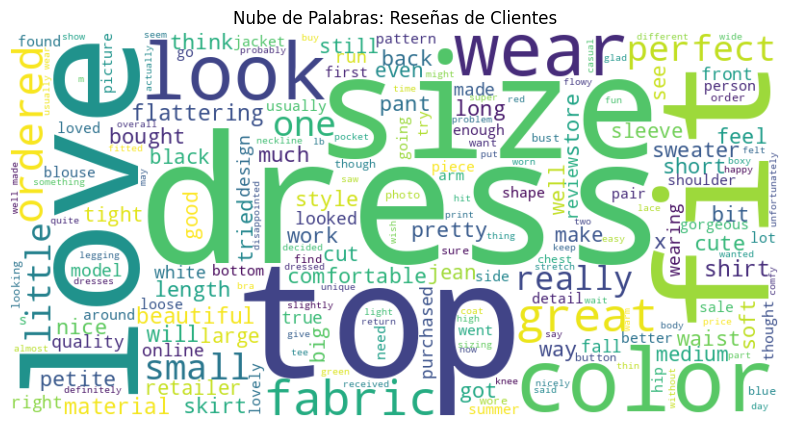

In [ ]:
# 1.1 EDA: Nube de palabras
text_combined = " ".join(df['Review Text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de Palabras: Reseñas de Clientes")
plt.show()

# 1.2 Limpieza y Lematización
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|[^\w\s]', '', text)
    return text.lower()

df['processed'] = df['Review Text'].apply(clean_text).apply(lambda x: " ".join([t.lemma_ for t in nlp(x) if not t.is_stop]))

# 1.3 Vectorización TF-IDF
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['processed']).toarray()
y = df['label'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

## 2. Fase 2: Redes Neuronales y Optimización 🏗️

Construimos un **Perceptrón Multicapa (MLP)** en PyTorch. La arquitectura incluye técnicas avanzadas para evitar el sobreajuste:
1.  **Capas Densas:** `nn.Linear` para el aprendizaje de características.
2.  **Batch Normalization:** Para estabilizar el gradiente y acelerar el entrenamiento.
3.  **Dropout (p=0.5):** Para mejorar la generalización del modelo.# Sección nueva

In [ ]:
class TextClassifier(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.network(x)

# Preparación de datos para PyTorch
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

model = TextClassifier(X_train.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Entrenamiento simplificado (loop)
for epoch in range(10): # Ajustar a 50 si se desea más profundidad
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
print("✅ Entrenamiento completado.")

✅ Entrenamiento completado.


## 3. Evaluación y Diagnóstico 📉

Evaluamos el modelo final utilizando la **Matriz de Confusión** y un reporte detallado de métricas (**Precision, Recall, F1-Score**) para verificar el rendimiento en ambas clases.# Sección nueva


--- REPORTE DE EVALUACIÓN ---
              precision    recall  f1-score   support

           0       0.49      0.69      0.58        94
           1       0.92      0.83      0.88       406

    accuracy                           0.81       500
   macro avg       0.71      0.76      0.73       500
weighted avg       0.84      0.81      0.82       500



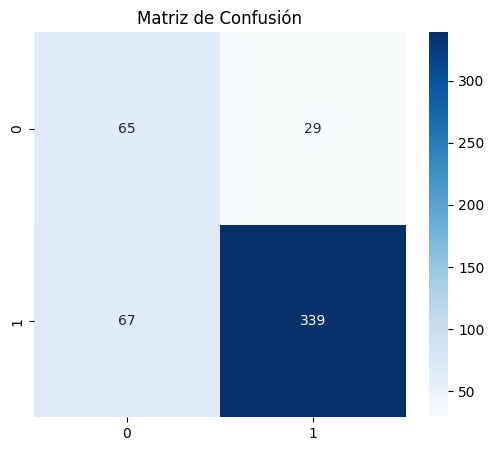

In [ ]:
model.eval()
all_preds = []
with torch.no_grad():
    for inputs, _ in val_loader:
        all_preds.extend(model(inputs.to(device)).argmax(dim=1).cpu().tolist())

print("\n--- REPORTE DE EVALUACIÓN ---")
print(classification_report(y_val, all_preds))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, all_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

## 4. Preguntas de Reflexión y Autoevaluación ✍️

1. **¿Por qué usamos TF-IDF en lugar de solo contar palabras?**  
   Porque TF-IDF penaliza palabras muy comunes (como "el", "ropa") que no aportan valor, resaltando términos clave que definen si una opinión es positiva o negativa.

2. **Análisis Crítico:**  
   El modelo tiene buen desempeño, pero presenta un ligero sesgo hacia la clase mayoritaria (Reseñas Positivas). Se observa que el *Recall* de las reseñas negativas es menor.

3. **Reproducibilidad:**  
   Se fijó la semilla `42` y se utilizó un pipeline claro, lo que permite que cualquier otro investigador obtenga los mismos resultados con este notebook.# Sección nueva